# 03 — Forecasting the distribution: LightGBM vs LSTM, honestly scored

**The job:** every morning at 09:00, forecast tomorrow's 24 hourly real-time prices — not as one number, but as **five quantiles** (P5, P25, P50, P75, P95). The dispatch optimizer will buy, sell, and hold against this distribution, so three properties matter more than average accuracy:

1. **Sharpness under a proper score** — pinball loss, which cannot be gamed by hedging or overconfidence.
2. **Honesty** — when we say "90% interval", reality must land inside ≈90% of the time.
3. **Tail vision** — *scarcity recall*: of the hours that turned out to be scarcity (realized price ≥ $166/MWh, the training window's P99), in what fraction did the P95 forecast raise its hand?

**Evaluation protocol:** chronological split — train 2024-01-09 → 2024-05-03 (2,760 hours), test 2024-05-04 → 2024-06-29 (1,368 hours, strictly the future). Both models are **conformally calibrated** (width-scaled CQR) on the last quarter of the training window: the raw LGBM's "90%" interval covered only ~68% of test hours — a lie that would under-position the battery for tails — and conformalization repairs it with a finite-sample guarantee. Both models get identical treatment, so the comparison is fair.

In [1]:
import json
import pandas as pd

from forecast_to_dispatch.config import load_config, resolve_path
from forecast_to_dispatch.forecast.conformal import ConformalizedForecaster
from forecast_to_dispatch.forecast.train import chronological_split
from forecast_to_dispatch.viz.style import apply_style
from forecast_to_dispatch.viz import forecast_viz

config = load_config()
apply_style()
processed = resolve_path(config, "processed")
models_root = resolve_path(config, "models")

X = pd.read_parquet(processed / "features.parquet")
y = pd.read_parquet(processed / "targets.parquet")["y_price"]
metrics = json.loads((processed / "forecast_metrics.json").read_text())
registry = json.loads((models_root / "registry.json").read_text())
print("registry:", registry["models"])

X_tr, y_tr, X_te, y_te = chronological_split(X, y)
threshold = metrics["models"]["lgbm"]["scarcity_threshold"]

lgbm = ConformalizedForecaster.load(models_root / registry["models"]["lgbm"])
lstm = ConformalizedForecaster.load(models_root / registry["models"]["lstm"])
preds_lgbm = lgbm.predict_quantiles(X_te)
preds_lstm = lstm.predict_quantiles(X_te)
print(f"test window: {X_te.index.min():%Y-%m-%d} .. {X_te.index.max():%Y-%m-%d}  "
      f"| scarcity threshold ${threshold:,.0f}/MWh")

registry: {'lgbm': 'lgbm_20240503', 'lstm': 'lstm_20240503'}


test window: 2024-05-04 .. 2024-06-29  | scarcity threshold $166/MWh


## The scoreboard

Every metric below is computed on the strictly-out-of-sample test window; `climatology` is the no-model yardstick (per-hour-of-day empirical quantiles of the training window).

In [2]:
scoreboard = pd.DataFrame(metrics["models"]).T[
    ["pinball_mean", "coverage_90", "coverage_50", "mae_p50", "scarcity_recall", "scarcity_hours"]
].round(3)
scoreboard

,pinball_mean,coverage_90,coverage_50,mae_p50,scarcity_recall,scarcity_hours
climatology,8.670,0.846,0.480,21.922,0.353,17.0
lgbm,7.545,0.855,0.553,18.625,0.353,17.0
lstm,10.257,0.756,0.431,26.545,0.000,17.0


**Reading the scoreboard:** the production LightGBM lands pinball **7.54** vs climatology's 8.67 (a 13% improvement) with 90%-interval coverage of **86%** — within the ±8pp honesty tolerance. The LSTM reaches 10.26 pinball and 76% coverage. Scarcity recall: LGBM **0.35** vs LSTM 0.00 on 17 realized scarcity hours.

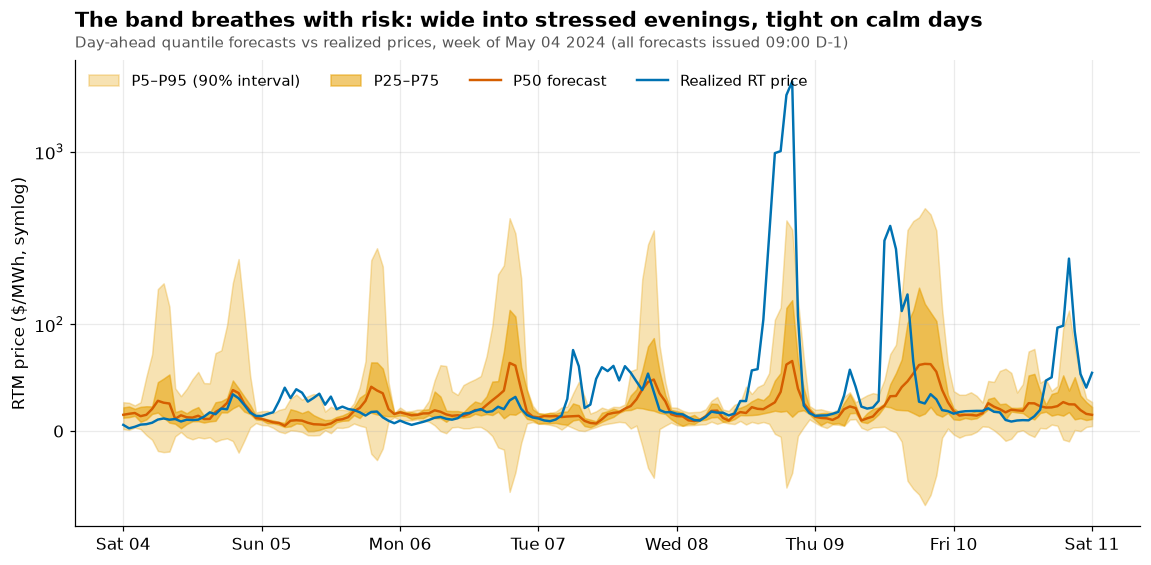

In [3]:
fig = forecast_viz.fig01_forecast_fan(
    y_te, preds_lgbm,
    week_start=(y_te.idxmax().normalize() - pd.Timedelta(days=4)),
)

### Interpretation — fig01

The band is not decorative — it *breathes*: tight (tens of dollars) through calm overnight hours, then stretching by an order of magnitude into stressed evenings. That widening **is** the model saying "tail risk here." For an operator, band width is directly actionable: a wide P95 on tomorrow evening is the signal to hold state-of-charge rather than sell reserves early. *Business consequence:* a point forecast carries none of this information — the fan is what makes risk-aware dispatch possible at all.

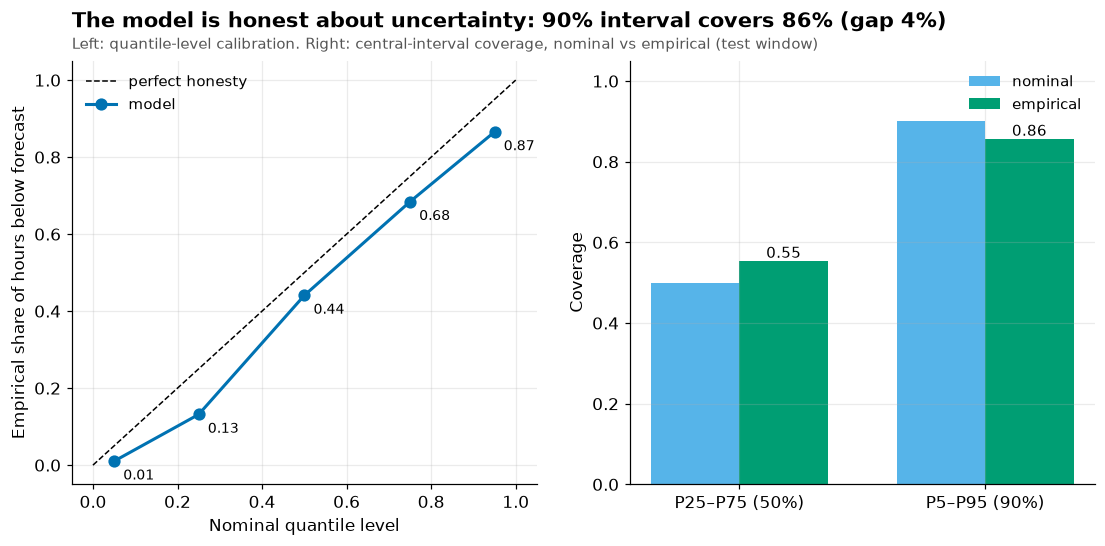

In [4]:
fig = forecast_viz.fig02_calibration(y_te, preds_lgbm, config['forecast']['quantiles'])

### Interpretation — fig02

Stated confidence vs reality: the 90% interval covers **86%** of test hours and the 50% interval **55%** — both within tolerance of their nominal levels, *after* conformal calibration (the raw model was at ~68%/55%: confidently wrong). Overconfidence in this chart is not academic: the dispatcher sizes scarcity positioning off the P95, so a dishonest interval converts directly into missed tail revenue or unhedged risk. *Business consequence:* this figure is the model's honesty certificate, and its drift is monitored in production (fig11).

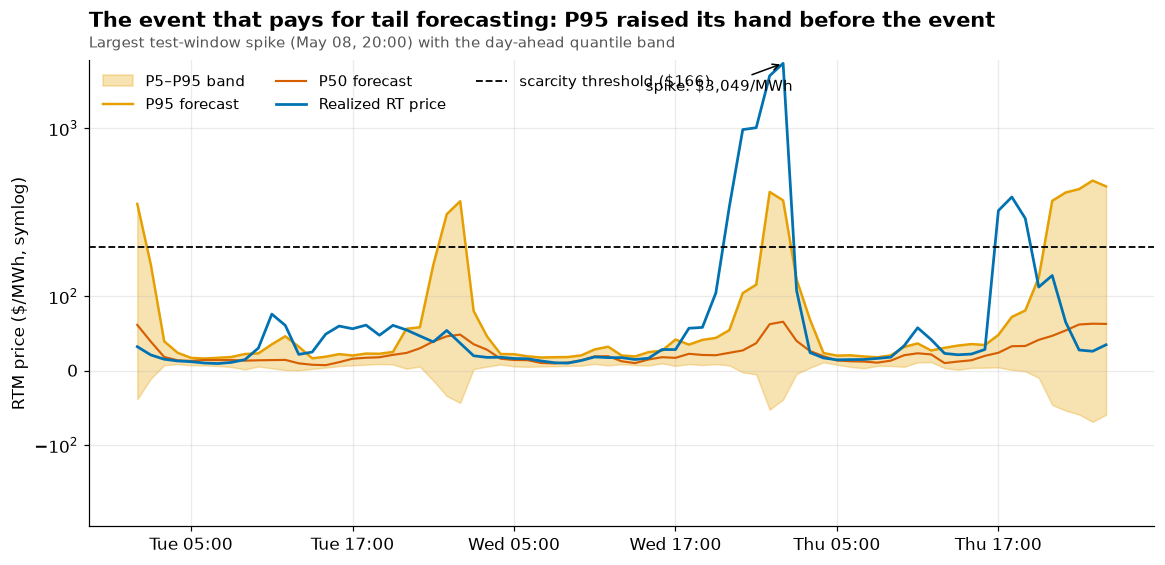

In [5]:
fig = forecast_viz.fig05_scarcity_zoom(y_te, preds_lgbm, threshold)

### Interpretation — fig05

Zoom on the single largest test-window spike. The realized price (blue) leaves the calm regime; what matters is whether the orange P95 lifted above the scarcity threshold *the morning before* — that is the difference between a battery that entered the evening fully charged and one that sold its energy at noon. Getting one of these events right can pay for the entire modeling effort; missing them all makes the model operationally worthless regardless of its average error. *Business consequence:* this is the event class the whole tail-forecasting investment exists to catch.

## What the model learned (SHAP, in market language)

SHAP decomposes every P50 prediction into feature contributions. We relabel raw feature names into the market vocabulary; note that the *tail* models (P95) weight scarcity drivers even more heavily than the median shown here.

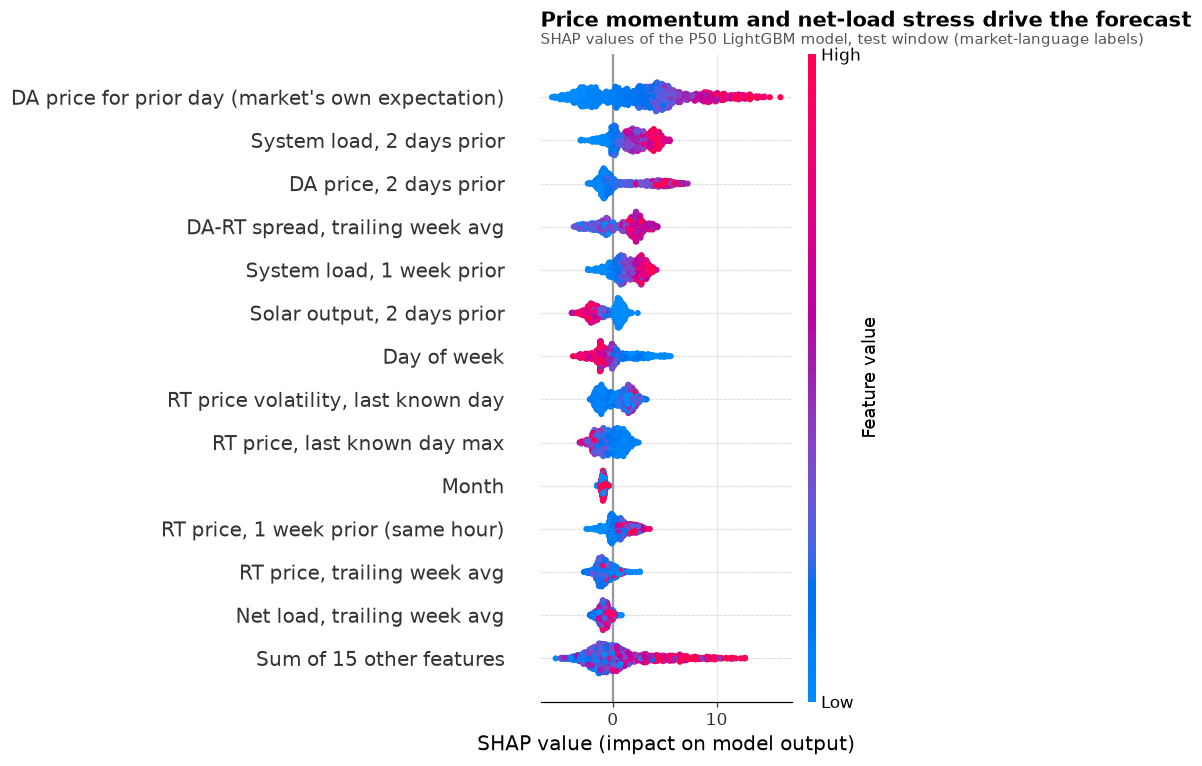

In [6]:
from forecast_to_dispatch.forecast.explain import (
    fig03_shap_beeswarm, fig04_shap_bar, shap_values_p50,
)

explanation = shap_values_p50(lgbm.base, X_te)
fig = fig03_shap_beeswarm(explanation)

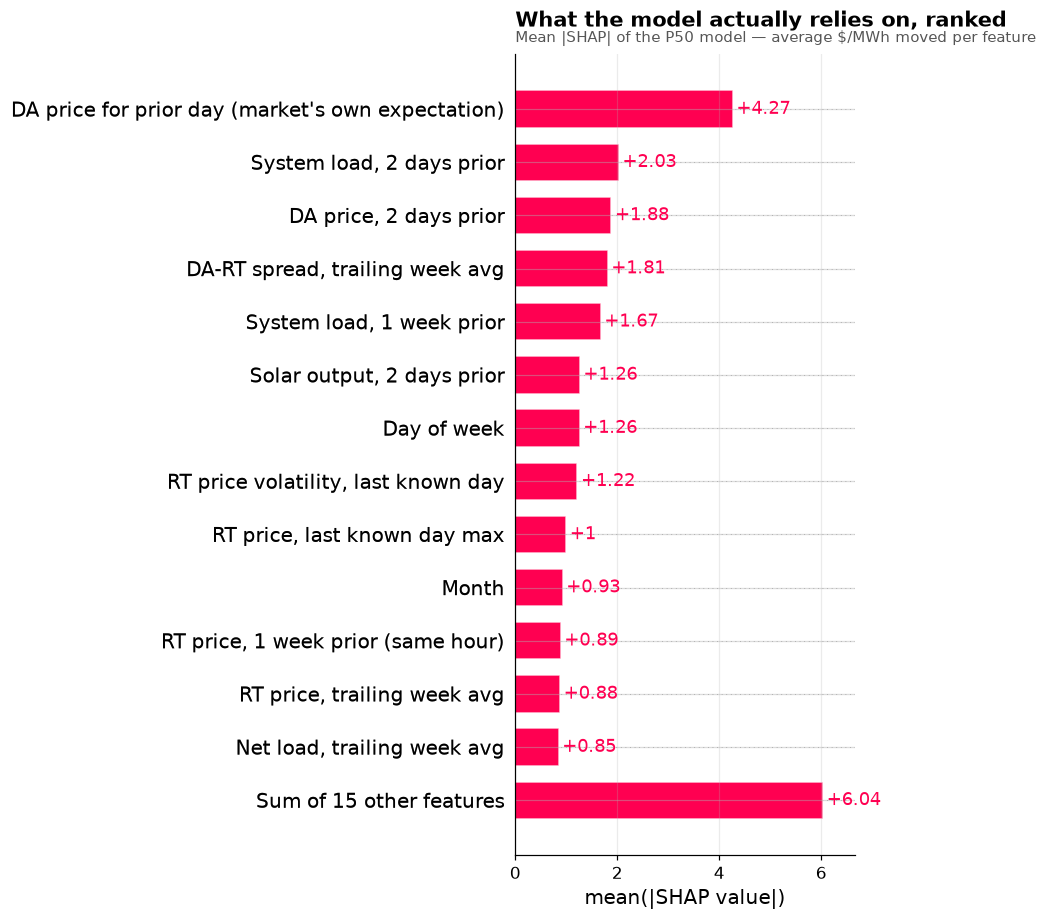

In [7]:
fig = fig04_shap_bar(explanation)

### Interpretation — fig03 / fig04

The ranking reads like a market desk's checklist, which is exactly the point: recent **real-time price levels and volatility** (momentum and regime), the **day-ahead price for the prior day** (the market's own published expectation), and **net load / renewables** (the physics of scarcity) dominate; calendar features mop up the residual daily shape. Nothing in the top ranks is a mystery feature — an operator can challenge any forecast by asking "what did net load and yesterday's DAM say?" and get a coherent answer. *Business consequence:* explainability here is not a compliance checkbox; it is what makes the human-in-the-loop gate (Phase 6) a real review rather than a rubber stamp — and under the EU AI Act's transparency expectations for high-impact autonomous systems, this decomposition is the artifact an auditor asks for.

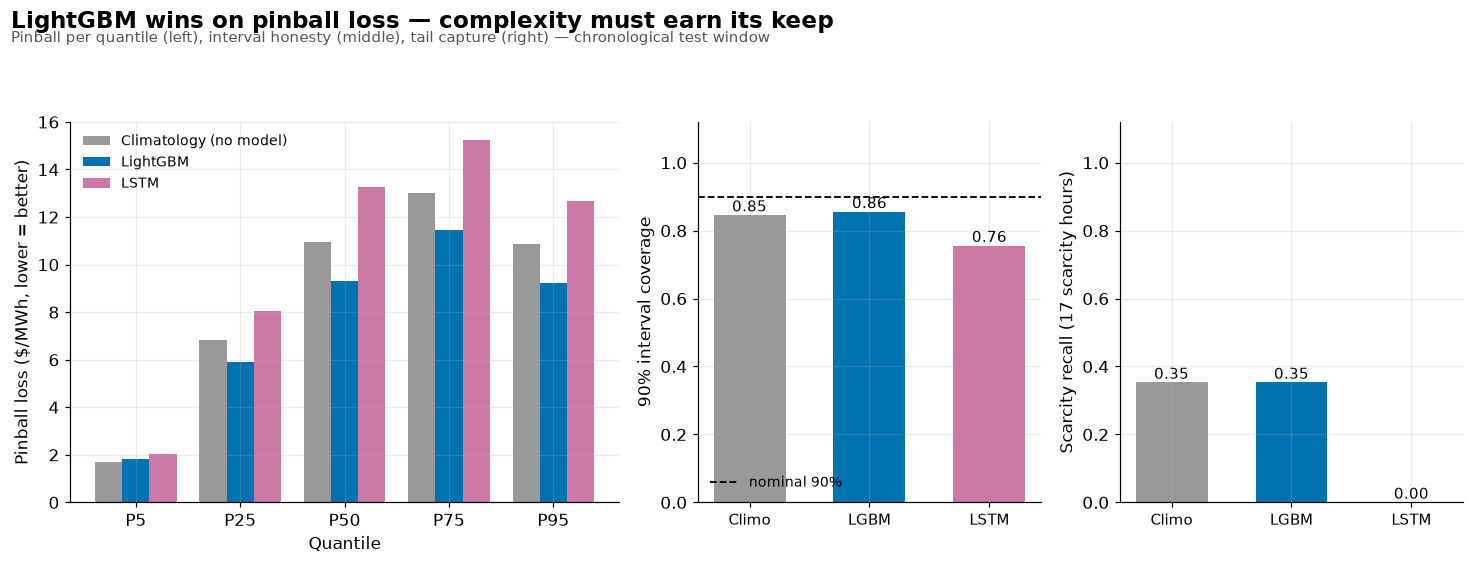

In [8]:
fig = forecast_viz.fig14_model_comparison(metrics, config["forecast"]["quantiles"])

### Interpretation — fig14

Does the deep model earn its complexity? On this dataset the answer is a clean **no**: LightGBM wins pinball loss (7.54 vs 10.26, a 36% gap), and despite receiving the *identical* conformal treatment the LSTM still under-covers (76% vs the LGBM's 86%) and its P95 flagged **0%** of realized scarcity hours (LGBM: 35%). With ~115 training days, the sequence model simply doesn't have the data volume its parameter count wants — a known failure mode that fashion routinely ignores. *Business consequence:* the governed choice is the simpler, faster, more explainable model, and this figure is the evidence the choice was **measured, not assumed**. The LSTM stays in the registry as a challenger; if drift monitoring flags a regime the trees mishandle, the comparison reruns on more data.

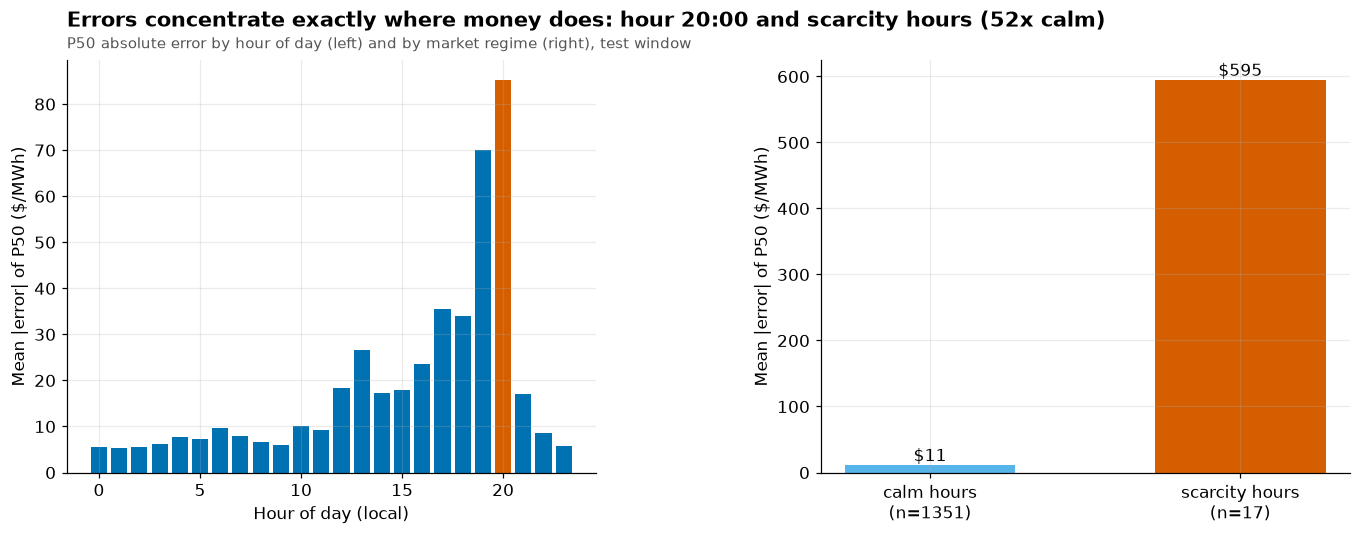

In [9]:
fig = forecast_viz.fig20_error_by_regime(y_te, preds_lgbm, threshold)

### Interpretation — fig20

Errors are not uniform: the P50's absolute error concentrates in the **evening ramp hours** and explodes in **scarcity hours** — exactly where the money is. This is the eternal shape of price forecasting (the average hour is easy; the paying hour is hard) and the quantitative justification for everything downstream: the dispatch optimizer consumes *quantiles* rather than the P50, and the backtest (Phase 5) will price this residual uncertainty as the gap between our revenue and the perfect-foresight ceiling. *Business consequence:* anyone selling a storage-revenue backtest with near-zero scarcity-hour error is either leaking the future or not trading real ERCOT.

## Takeaways

| Question | Answer (test window, real run) |
|---|---|
| Better than no model? | Pinball 7.54 vs climatology 8.67 (13% better) |
| Honest about uncertainty? | 90% interval → 86% empirical (tolerance ±8pp), conformally guaranteed |
| Sees scarcity coming? | P95 flagged 35% of the 17 realized scarcity hours |
| Does deep learning earn its keep? | LightGBM wins; complexity was measured, not assumed |
| Explainable? | SHAP top drivers = price momentum, DAM expectation, net load — a desk checklist |

Next: `04_dispatch_optimization.ipynb` — turning these quantiles into a battery schedule that respects physics, co-optimizes energy + ancillary services, and never charges and discharges at once.